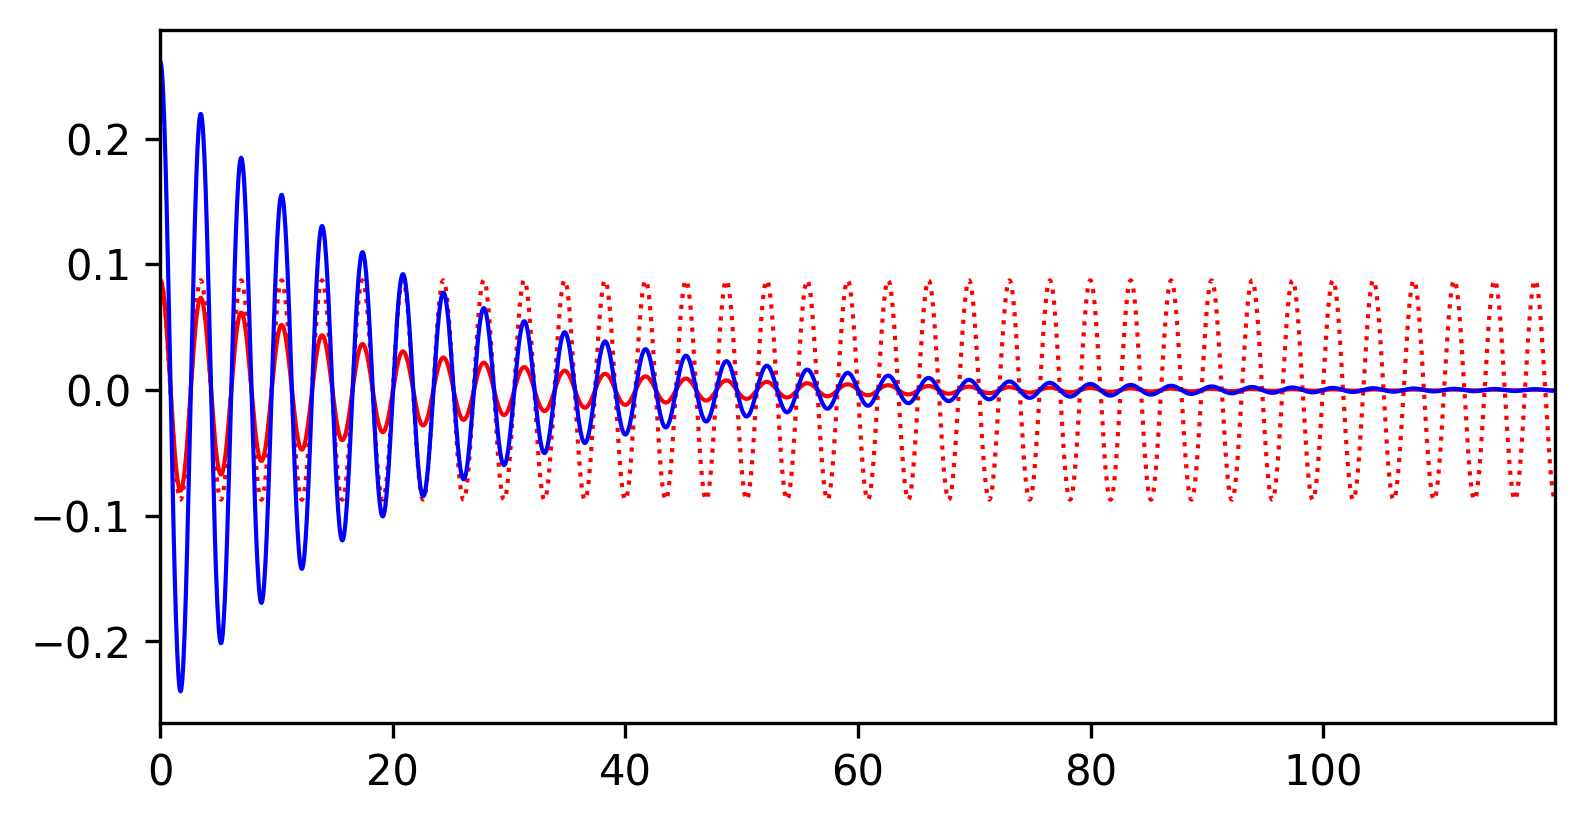

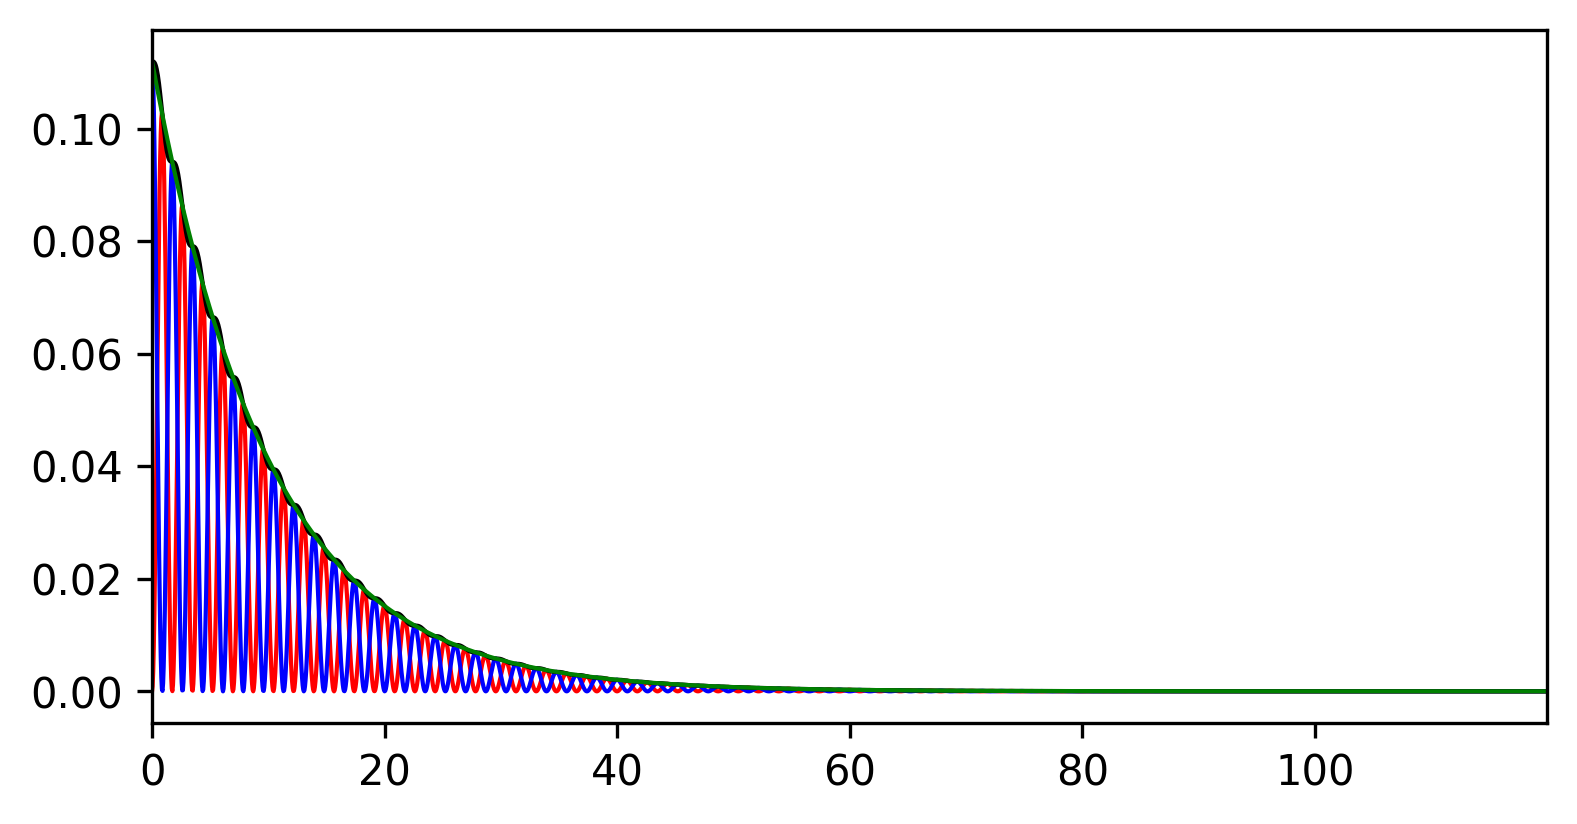

In [72]:

import numpy as np 
import matplotlib.pyplot as plt 

# Parameters
m = 1
length = 3
g = 9.80665
theta0 = np.deg2rad(5)
omega0 = 0.0
dt = 0.05
tmax = 120
beta = 0.1
# Initialize
theta = theta0
omega = omega0
origin = np.array([0.0, 0.0])

# Arrays to store results
t = np.arange(0, tmax, dt)

def acc(t,theta,omega,):
    return - (g / length)*np.sin(theta) - beta*omega

def verlet(t, func, r0, v0):
    r = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)
    dt = t[1] - t[0]

    r[0] = r0
    v[0] = v0
    a[0] = func(t[0], r[0], v[0])

    for i in range(len(t) - 1):
        r[i+1] = r[i] + v[i] * dt + 0.5 * a[i] * dt**2
        a[i+1] = func(t[i+1], r[i+1], v[i] + 0.5 * a[i] * dt)  
        v[i+1] = v[i] + 0.5 * (a[i] + a[i+1]) * dt             
    return r, v, a

def rk4(t, func, r0, v0):
    r = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)
    dt = t[1] - t[0]

    r[0] = r0
    v[0] = v0
    a[0] = func(t[0], r[0], v[0])
    
    for i in range(len(t)-1):
        # RK4 coefficients for position and velocity
        k1v = func(t[i], r[i], v[i])
        k1r = v[i]
        k2v = func(t[i] + dt/2, r[i] + k1r*dt/2, v[i] + k1v*dt/2)
        k2r = v[i] + k1v*dt/2
        k3v = func(t[i] + dt/2, r[i] + k2r*dt/2, v[i] + k2v*dt/2)
        k3r = v[i] + k2v*dt/2
        k4v = func(t[i] + dt, r[i] + k3r*dt, v[i] + k3v*dt)
        k4r = v[i] + k3v*dt
        # Update position and velocity
        v[i+1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) * dt / 6
        r[i+1] = r[i] + (k1r + 2*k2r + 2*k3r + k4r) * dt / 6
        a[i+1] = func(t[i+1], r[i+1], v[i+1])
    return r, v, a

theta, omega, omegadot = rk4(t,acc,theta0,omega0)

beta = 0 
thetab, omegab, omegadotb = rk4(t,acc,theta0,omega0)
beta = 0.1

# Convert to Cartesian coordinates
x = length * np.sin(theta)
y = -length * np.cos(theta)
plt.figure(figsize=(6,3),dpi=300)
plt.plot(t,theta ,'r-',lw=1)
plt.plot(t,thetab,'r:',lw=1)
plt.plot(t,x,'b-',lw=1)
plt.xlim(t.min(),t.max())
plt.show()

KE = 0.5 * m * (length * omega)**2
PE = m * g * length * (1- np.cos(theta))
TE = KE + PE 
TEf = TE[0]*np.exp(-beta*t)
plt.figure(figsize=(6,3),dpi=300)
plt.plot(t,KE,'r-',lw=1)
plt.plot(t,PE,'b-',lw=1)
plt.plot(t,TE,'k-',lw=1)
plt.plot(t,TEf,'g-',lw=1)
plt.xlim(t.min(),t.max())
plt.show()


In [73]:
from scipy.optimize import curve_fit

# Define exponential decay function for fitting
def exp_decay(t, E0, beta_fit):
    return E0 * np.exp(-beta_fit * t)

# Fit the total energy to exponential decay
popt, pcov = curve_fit(exp_decay, t, TE, p0=[np.mean(TE), 0.1])

# Extract best-fit parameters and uncertainties
E0_fit, beta_fit = popt
E0_err, beta_err = np.sqrt(np.diag(pcov))

print(f"Best-fit E0  : {E0_fit:.4f} ± {2*E0_err:.4f}, Actual E0   = {TE[0]:.4f}")
print(f"Best-fit beta: {beta_fit:.4f} ± {2*beta_err:.4f}, Actual beta = {beta:.4f}")

Best-fit E0  : 0.1124 ± 0.0001, Actual E0   = 0.1120
Best-fit beta: 0.1003 ± 0.0002, Actual beta = 0.1000


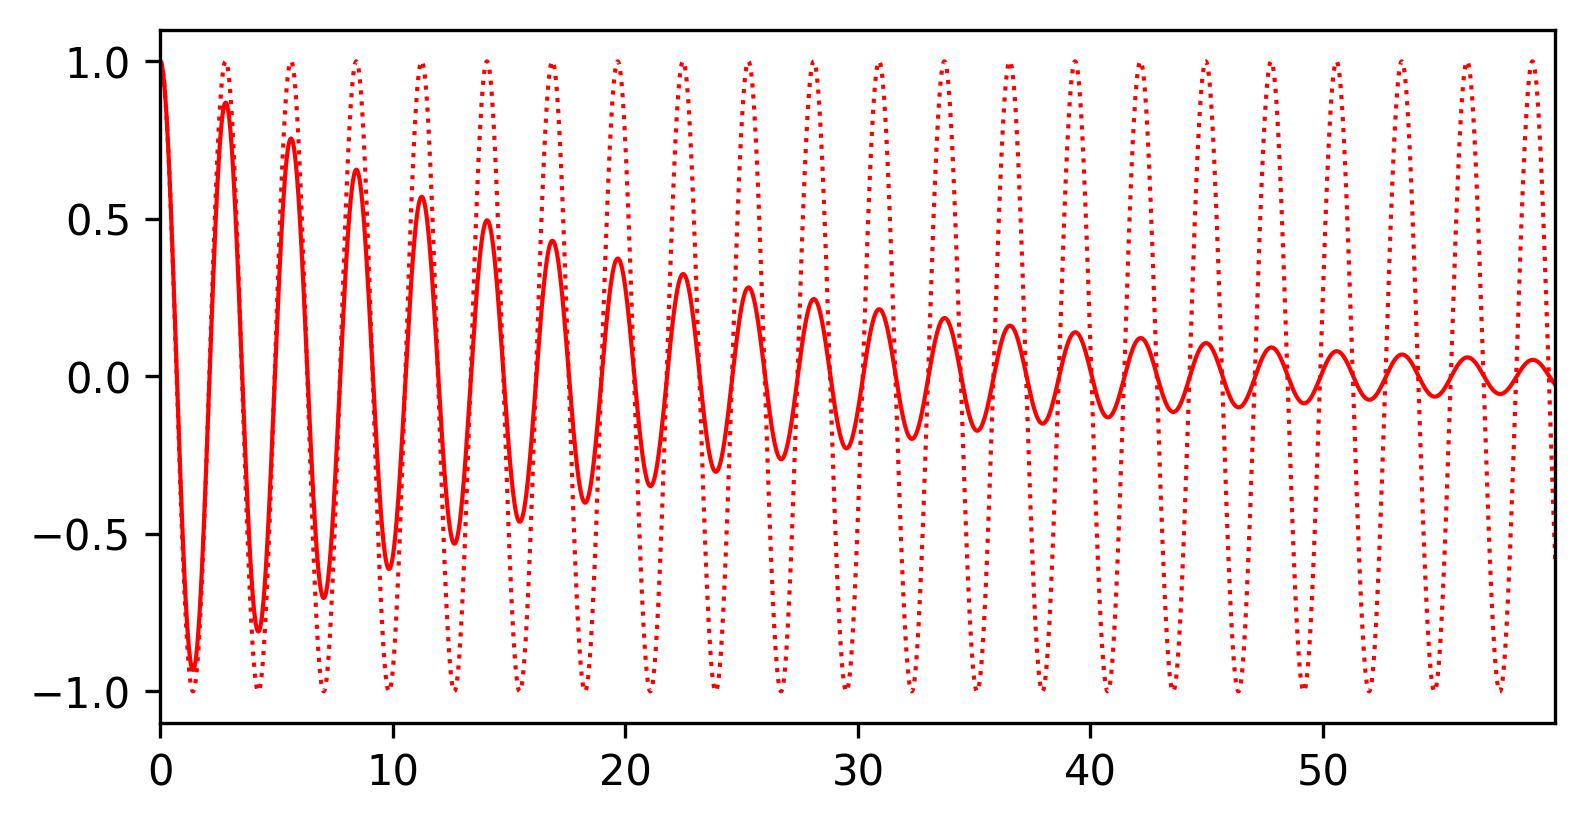

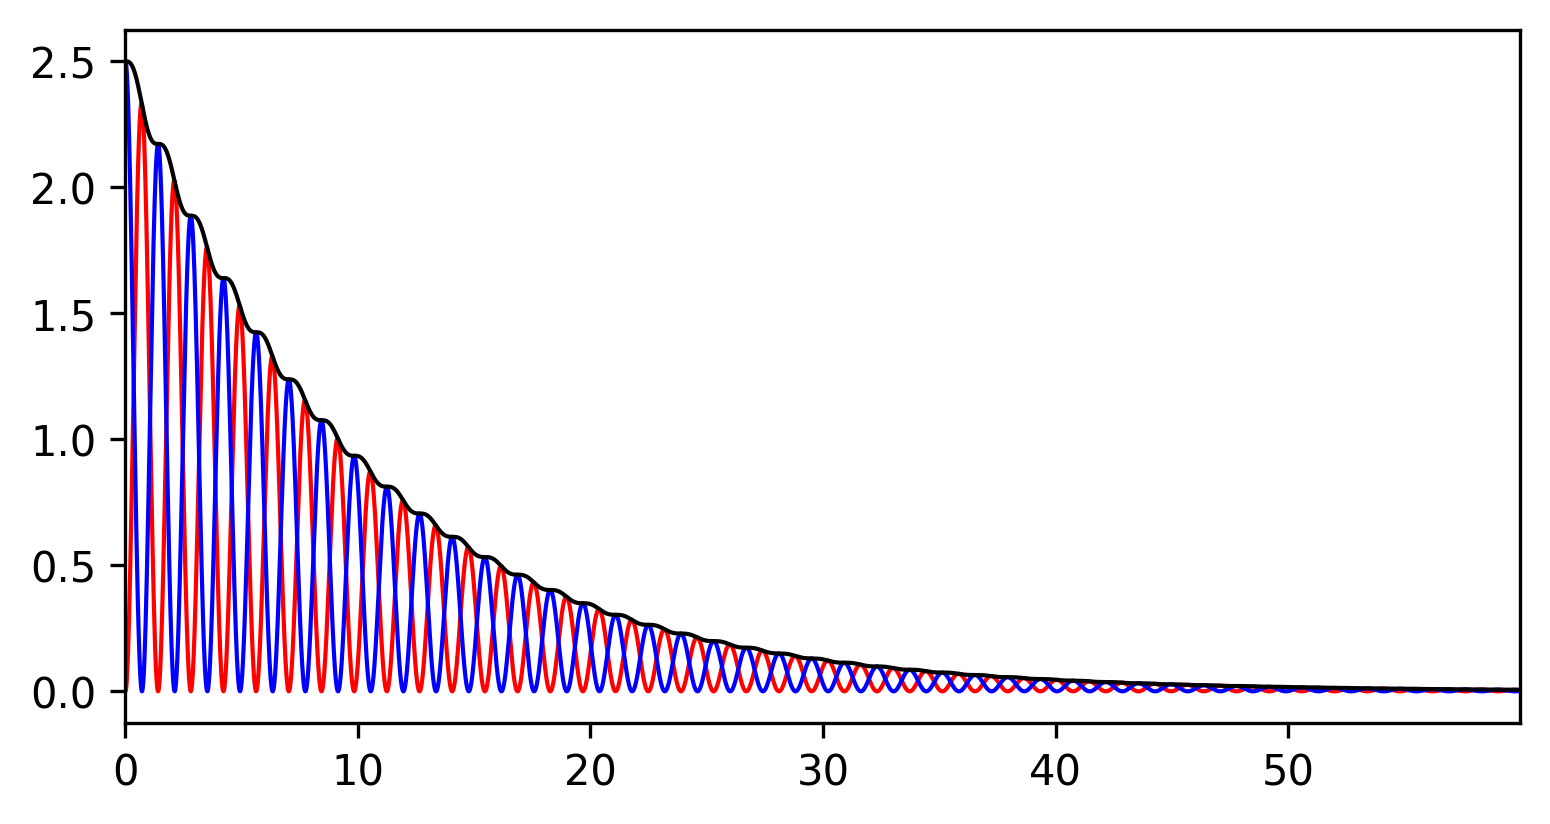

In [135]:

import numpy as np 
import matplotlib.pyplot as plt 

# Parameters
m = 1
x0 = 1
v0 = 0
dt = 0.01
k = 5
tmax = 60
beta = 0.1
# Initialize
x = x0
v = v0
# Arrays to store results
t = np.arange(0, tmax, dt)

def acc(t,x,v):
    return -(beta/m)*v - (k/m)*x 

x,v,a = rk4(t,acc,x0,v0)

betab = beta
beta = 0 
xb, vb, ab = rk4(t,acc,x0,v0)
beta = betab

plt.figure(figsize=(6,3),dpi=300)
plt.plot(t,x ,'r-',lw=1)
plt.plot(t,xb,'r:',lw=1)
plt.xlim(t.min(),t.max())
plt.show()

KE = 0.5 * m * v**2
PE = 0.5 * k * x**2
TE = KE + PE 
TEf = TE[0]*np.exp(-(beta/m)*t)

plt.figure(figsize=(6,3),dpi=300)
plt.plot(t,KE,'r-',lw=1)
plt.plot(t,PE,'b-',lw=1)
plt.plot(t,TE,'k-',lw=1)
#plt.plot(t,TEf,'g-',lw=1)
plt.xlim(t.min(),t.max())
plt.show()


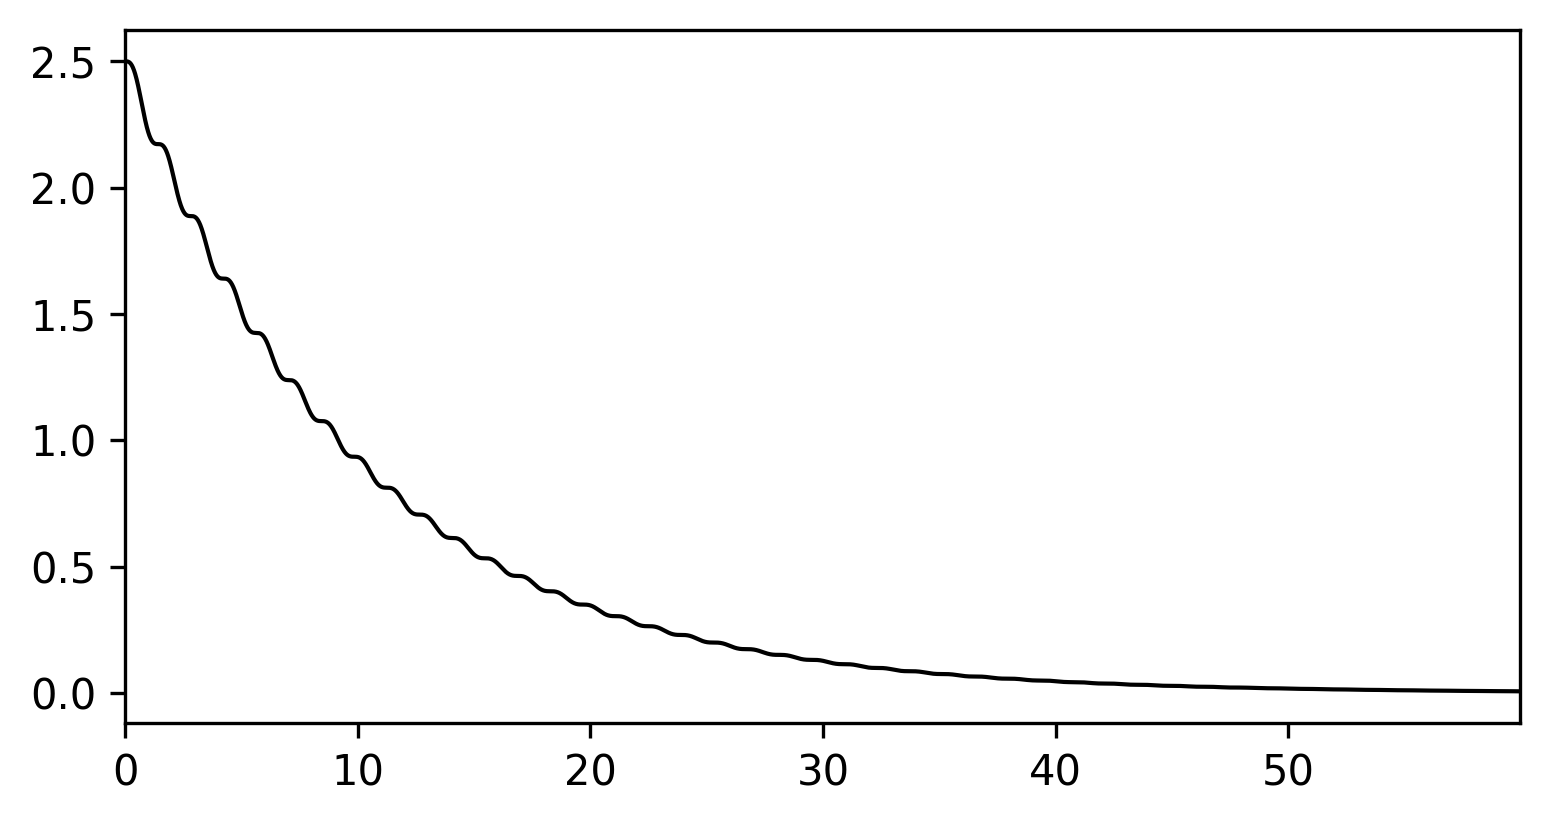

In [132]:
def If(x):
    N = len(x)
    dx = x[1]-x[0]
    I = np.zeros((N,N))
    for i in range(N):
        I[i,:i] = 2
        I[i, 0] = 1 
        I[i, i] = 1 
    I *= dx/2 
    return I
def Df(x):
    N = len(x)
    dx = x[1] - x[0]
    D = np.zeros((N, N))
    for i in range(1, N-1):
        D[i, i+1] = 1
        D[i, i-1] = -1
    D[0, :3] = [-3, 4, -1]
    D[-1, -3:] = [1, -4, 3]
    D /= (2 * dx)
    return D
def DDf(x):
    N = len(x)
    dx = x[1] - x[0]
    D2 = np.zeros((N, N))
    for i in range(1, N-1):
        D2[i, i-1] = 1
        D2[i, i] = -2
        D2[i, i+1] = 1
    D2[0, :4] = [2, -5, 4, -1]
    D2[-1, -4:] = [-1, 4, -5, 2]
    D2 /= (dx ** 2)
    return D2


E = If(t)@(-beta * v**2)
plt.figure(figsize=(6,3),dpi=300)
plt.plot(t,E+TE[0],'k-',lw=1)
plt.xlim(t.min(),t.max())
plt.show()

We start with the pendulum equation.
$$
    m\ell^2\ddot\theta + \beta\dot\theta + mg\ell\sin\theta=0
$$
we simplify to
$$
    \ddot \theta +\frac{\beta}{m\ell^2}\dot \theta + \frac{g}{\ell}\sin\theta=0
$$

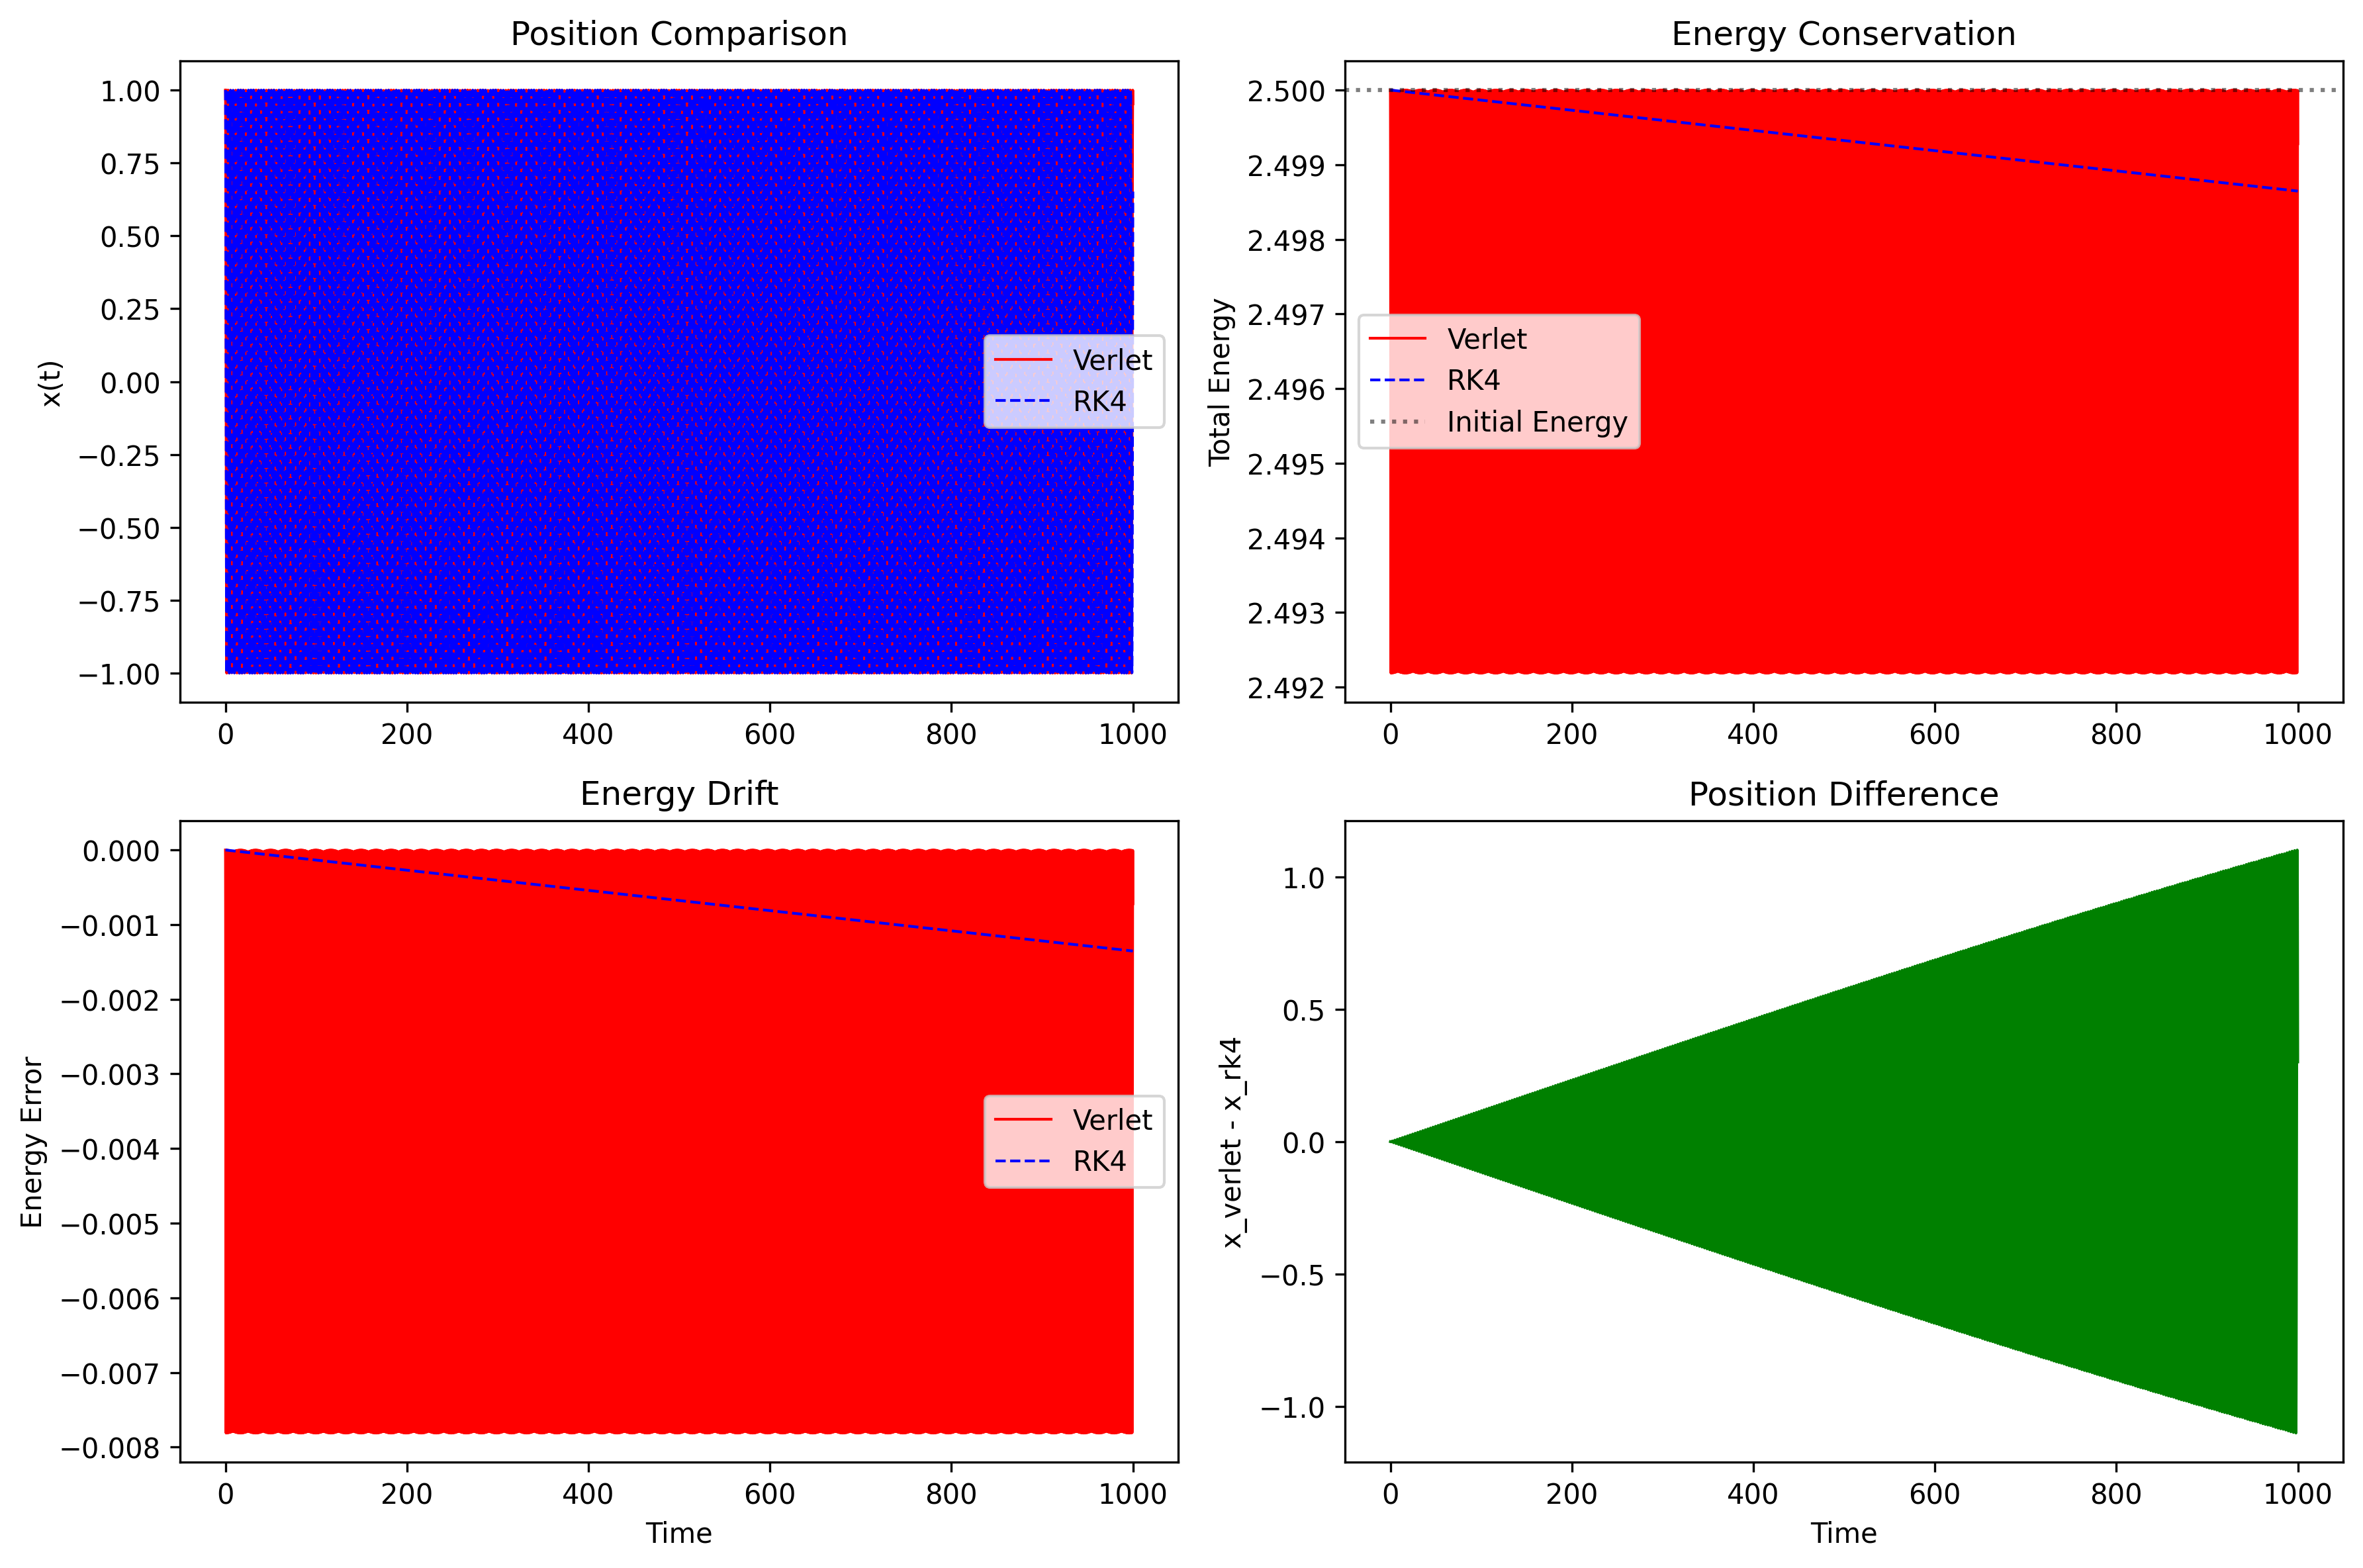

Verlet - Final energy: 2.499280, Error: -0.000720
RK4    - Final energy: 2.498646, Error: -0.001354


In [71]:

import numpy as np 
import matplotlib.pyplot as plt 

# Parameters
m = 1
x0 = 1
v0 = 0.0
dt = 0.05
k = 5
tmax = 1000
beta = 0
# Initialize
x = x0
v = v0
# Arrays to store results
t = np.arange(0, tmax, dt)

def acc(t,x,v):
    return -(k/m)*x - (beta/m)*v

def verlet(t, func, r0, v0):
    r = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)
    dt = t[1] - t[0]

    r[0] = r0
    v[0] = v0
    a[0] = func(t[0], r[0], v[0])

    for i in range(len(t) - 1):
        r[i+1] = r[i] + v[i] * dt + 0.5 * a[i] * dt**2
        a[i+1] = func(t[i+1], r[i+1], v[i] + 0.5 * a[i] * dt)  
        v[i+1] = v[i] + 0.5 * (a[i] + a[i+1]) * dt             
    return r, v, a

def rk4(t, func, r0, v0):
    r = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)
    dt = t[1] - t[0]

    r[0] = r0
    v[0] = v0
    a[0] = func(t[0], r[0], v[0])
    
    for i in range(len(t)-1):
        # RK4 coefficients for position and velocity
        k1v = func(t[i], r[i], v[i])
        k1r = v[i]
        k2v = func(t[i] + dt/2, r[i] + k1r*dt/2, v[i] + k1v*dt/2)
        k2r = v[i] + k1v*dt/2
        k3v = func(t[i] + dt/2, r[i] + k2r*dt/2, v[i] + k2v*dt/2)
        k3r = v[i] + k2v*dt/2
        k4v = func(t[i] + dt, r[i] + k3r*dt, v[i] + k3v*dt)
        k4r = v[i] + k3v*dt
        # Update position and velocity
        v[i+1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) * dt / 6
        r[i+1] = r[i] + (k1r + 2*k2r + 2*k3r + k4r) * dt / 6
        a[i+1] = func(t[i+1], r[i+1], v[i+1])
    return r, v, a

# Calculate both integrations
xv, vv, av = verlet(t, acc, x0, v0)  # verlet
xr, vr, ar = rk4(t, acc, x0, v0)     # rk4

# Calculate energies for both methods
KEr = 0.5 * m * vr**2
PEr = 0.5 * k * xr**2
TEr = KEr + PEr 

KEv = 0.5 * m * vv**2
PEv = 0.5 * k * xv**2
TEv = KEv + PEv

# Create comparison plots
plt.figure(figsize=(12, 8), dpi=300)

# Position comparison
plt.subplot(2, 2, 1)
plt.plot(t, xv, 'r-', lw=1, label='Verlet')
plt.plot(t, xr, 'b--', lw=1, label='RK4')
plt.ylabel('x(t)')
plt.legend()
plt.title('Position Comparison')

# Total energy comparison
plt.subplot(2, 2, 2)
plt.plot(t, TEv, 'r-', lw=1, label='Verlet')
plt.plot(t, TEr, 'b--', lw=1, label='RK4')
plt.axhline(y=TEv[0], color='k', linestyle=':', alpha=0.5, label='Initial Energy')
plt.ylabel('Total Energy')
plt.legend()
plt.title('Energy Conservation')

# Energy difference (to see drift)
plt.subplot(2, 2, 3)
plt.plot(t, TEv - TEv[0], 'r-', lw=1, label='Verlet')
plt.plot(t, TEr - TEr[0], 'b--', lw=1, label='RK4')
plt.ylabel('Energy Error')
plt.xlabel('Time')
plt.legend()
plt.title('Energy Drift')

# Position difference
plt.subplot(2, 2, 4)
plt.plot(t, xv - xr, 'g-', lw=1)
plt.ylabel('x_verlet - x_rk4')
plt.xlabel('Time')
plt.title('Position Difference')

plt.tight_layout()
plt.show()

# Print energy conservation statistics
print(f"Verlet - Final energy: {TEv[-1]:.6f}, Error: {TEv[-1]-TEv[0]:.6f}")
print(f"RK4    - Final energy: {TEr[-1]:.6f}, Error: {TEr[-1]-TEr[0]:.6f}")

C:\Users\verci\AppData\Local\Temp\ipykernel_13696\974943541.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  InfoStr='Fit: y = '+"{:.5f}".format(float(a))+'x + '+"{:.5f}".format(float(b))#


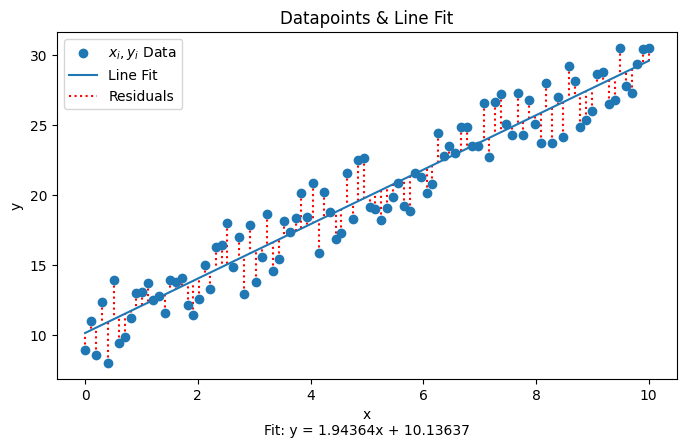

In [ ]:
###------------------- Beginning of Code: Import Modules -------------------###
import numpy as np; import random; from matplotlib import pyplot as plt       #
###----------------- Make a Dataset & Calculate Best Fit Line --------------###
    b_,N,R] = [2,10,100,6]; x = np.linspace(0,10,N); y = a_*x + b_ # Dataset  #
for i in range(N): y[i] = y[i] + R*(random.random()-0.5) # Add randomness to y#
[SX2,SX,SXY,SY] = [sum(x**2),sum(x),sum(x*y),sum(y)] # Calculate sums of data #
[M,V] = [np.array([[SX2,SX],[SX,N]]),np.array([[SXY],[SY]])] # Matrix & vector#
[a,b] = np.dot(np.linalg.inv(M),V); y_f = a*x + b # Matrix equation; fit line #
###--------------------------- Plot the Results ----------------------------###
plt.subplots(figsize=[8,4.5]); plt.scatter(x,y), plt.plot(x,y_f) # Plot data  #
for i in range(N): plt.plot([x[i],x[i]],[y[i],y_f[i]],':',color='r',zorder=0) #
InfoStr='Fit: y = '+"{:.5f}".format(float(a))+'x + '+"{:.5f}".format(float(b))#
plt.xlabel('x\n'+InfoStr), plt.ylabel('y'),plt.title('Datapoints & Line Fit') #
plt.legend(['${x_i,y_i}$ Data','Line Fit','Residuals']) # Add legend to plot  #
###----------------------------- End of Code -------------------------------###

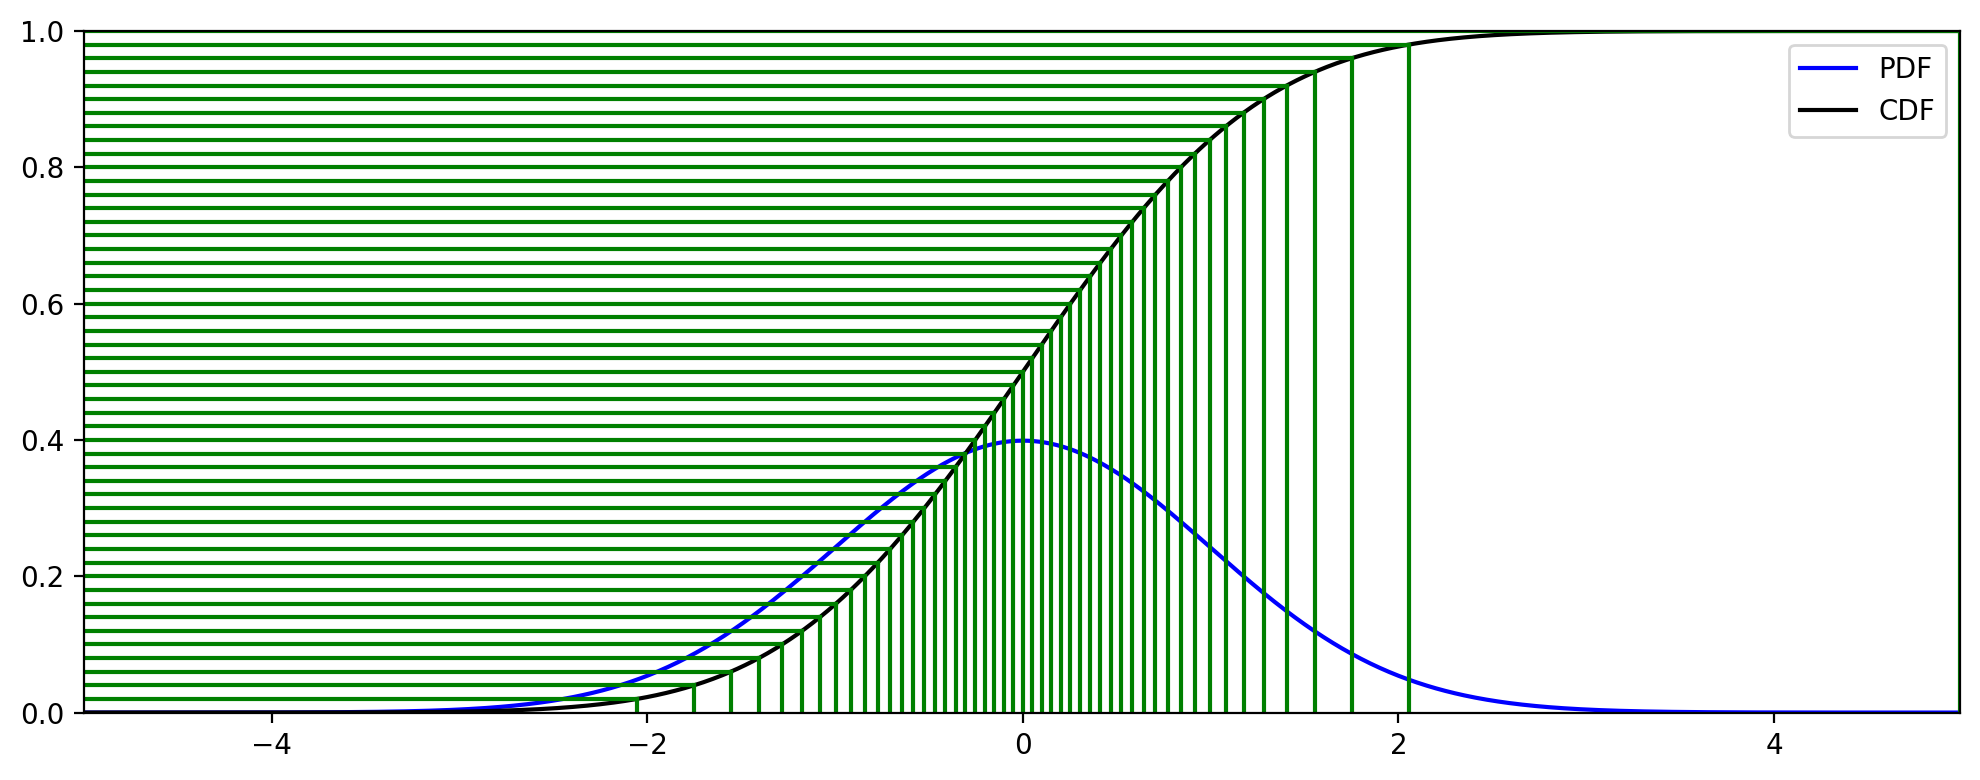

In [213]:
x = np.arange(-5,5,0.01)
pdf = np.exp(-0.5 *x**2) 
pdf /= (If(x)@pdf)[-1]
cdf = If(x)@pdf

# Find x values corresponding to equally spaced y values
ypts = np.linspace(0,1,51)
xpts = np.interp(ypts, cdf, x)

plt.figure(figsize=(10,4),dpi=200)

#plt.subplot(1,2,1)
plt.plot(x, pdf, 'b-', label='PDF')
plt.plot(x, cdf, 'k-', label='CDF')
for xi,yi in zip(xpts,ypts):
    plt.plot([-5,xi],[yi,yi],'g-')
    plt.plot([xi,xi], [0,yi],'g-')
plt.ylim(0,1)
plt.legend()
plt.xlim(x.min(),x.max())
# plt.subplot(1,2,2)
# plt.plot(xpts, ypts, 'r-', markersize=2)

# plt.xlabel('x')
# plt.ylabel('CDF')
# plt.title('Inverse CDF')
# plt.grid(True)

plt.tight_layout()
plt.show()

0.997
[3.11343888 3.00434805 3.89322245]
0.964
[-2.49594542 -2.27087681  2.10655617 -2.27300939  2.52440683  2.70324949
 -2.89227892 -2.19029334  2.50038629  2.25352115  2.22906416 -2.01219832
 -2.23311201  2.33101566 -2.4766459   2.10914393  2.16138745  3.11343888
  3.00434805 -2.3784277   2.03860686  2.02280336  2.83426242  2.45440173
 -2.048661   -2.06439828  2.57803765 -2.48874258  3.89322245 -2.21018506
  2.75850751 -2.22439949 -2.43631119 -2.72246023 -2.53649404 -2.05822802]


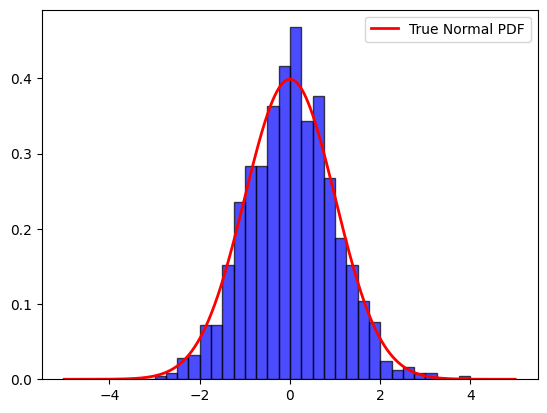

In [236]:
import numpy as np

# Create the normal CDF first
x = np.arange(-5, 5, 0.01)
pdf = np.exp(-x**2/2) / np.sqrt(2*np.pi)  # Normal PDF
cdf = If(x)@pdf  # Your integration matrix

# Generate uniform random and transform to normal
normal_samples = []
# for i in range(1000): 
#     y = np.random.random()           # Uniform [0,1]
#     x_sample = np.interp(y, cdf, x)  # Transform to normal
#     normal_samples.append(x_sample)
N = 1000
normal_samples = np.random.normal(0,1,N) #np.random.normal(0,1,N)
sigma2events = normal_samples[np.abs(normal_samples)>2]
sigma3events = normal_samples[np.abs(normal_samples)>3]
print((N-len(sigma3events))/N)
print(sigma3events)
print((N-len(sigma2events))/N)
print(sigma2events)
# Plot the result
plt.hist(normal_samples, bins=np.arange(-5,5,0.25), color = 'b',density=True, alpha=0.7, edgecolor='k')
plt.plot(x, pdf, 'r-', lw=2, label='True Normal PDF')
plt.legend()
plt.show()

In [1]:
N = 500
x = np.random.normal(0,1,N)
y = np.random.normal(0,1,N)

radius = np.arange(0,6,1)
theta = np.linspace(0,2*np.pi,1000)
for r in radius:
    plt.plot(r*np.cos(theta),r*np.sin(theta),'k-', alpha=0.5,zorder = 1)
theta = np.arange(0,2*np.pi,np.pi/6)
for t in theta:
    plt.plot([0,5*np.cos(t)],[0,r*np.sin(t)],'k-',alpha =0.5,zorder = 1)
plt.scatter(x,y,color='k',zorder=2,marker='.')
plt.gca().set_aspect('equal')
plt.xlim(-5,5);plt.ylim(-5,5)
plt.show()

r = np.sqrt(x*x+y*y)
plt.hist(r,bins=np.arange(0,5,0.25),color='w',edgecolor='k',density=True)
rs = np.arange(0,5,0.05)
plt.plot(rs, rs*np.exp(-0.5*rs**2),'r-')
plt.xlim(rs.min(),rs.max())

NameError: name 'np' is not defined

In [1]:
print(5/4.5)

1.1111111111111112
